<a href="https://colab.research.google.com/github/SruthiGS-Gito/Case-Study---Assignment-MLAI-B3/blob/main/Case_Study_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("punkt_tab")

from sklearn.feature_extraction.text import TfidfVectorizer
!pip install gensim
from gensim.models import Word2Vec

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ( accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report )
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.svm import LinearSVC

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


# Load Data

In [2]:
import kagglehub

path = kagglehub.dataset_download("arunasivapragasam/donors-choose")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'donors-choose' dataset.
Path to dataset files: /kaggle/input/donors-choose


# EDA

In [3]:
file_path = path + "/Preprocessed_DonorsChoose_dataset.csv"
df_donors = pd.read_csv(file_path)
df_donors.head()

,id,teacher_prefix,school_state,project_grade_category,project_subject_categories,project_subject_subcategories,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,cleaned_titles,cleaned_essays,cleaned_summary,isdigit_summary
0,p253737,mrs,in,grades_prek_2,literacy_language,esl_literacy,0,0,154.60,23,educational support english learners home,students english learners working english seco...,students_need_opportunities_practice_beginning...,0
1,p258326,mr,fl,grades_6_8,history_civics_health_sports,civics_government_teamsports,7,1,299.00,1,wanted projector hungry learners,students arrive school eager learn polite gene...,students_need_projector_help_viewing_education...,0
2,p182444,ms,az,grades_6_8,health_sports,health_wellness_teamsports,1,0,516.85,22,soccer equipment awesome middle school students,true champions not always ones win guts mia ha...,students_need_shine_guards_athletic_socks_socc...,0
3,p246581,mrs,ky,grades_prek_2,literacy_language_math_science,literacy_mathematics,4,1,232.90,4,techie kindergarteners,work unique school filled esl english second l...,students_need_engage_reading_math_way_inspire_...,0
4,p104768,mrs,tx,grades_prek_2,math_science,mathematics,1,1,67.98,4,interactive math tools,second grade classroom next year made around 2...,students_need_hands_practice_mathematics_fun_p...,0


In [4]:
df_donors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109248 entries, 0 to 109247
Data columns (total 14 columns):
 #   Column                                        Non-Null Count   Dtype  
---  ------                                        --------------   -----  
 0   id                                            109248 non-null  object 
 1   teacher_prefix                                109248 non-null  object 
 2   school_state                                  109248 non-null  object 
 3   project_grade_category                        109248 non-null  object 
 4   project_subject_categories                    109248 non-null  object 
 5   project_subject_subcategories                 109248 non-null  object 
 6   teacher_number_of_previously_posted_projects  109248 non-null  int64  
 7   project_is_approved                           109248 non-null  int64  
 8   price                                         109248 non-null  float64
 9   quantity                                      10

In [5]:
df_donors.shape

(109248, 14)

In [6]:
df_donors.describe()

,teacher_number_of_previously_posted_projects,project_is_approved,price,quantity,isdigit_summary
count,109248.000000,109248.000000,109248.000000,109248.000000,109248.000000
mean,11.153165,0.848583,298.119343,16.965610,0.144222
std,27.777154,0.358456,367.498030,26.182942,0.351317
min,0.000000,0.000000,0.660000,1.000000,0.000000
25%,0.000000,1.000000,104.310000,4.000000,0.000000
50%,2.000000,1.000000,206.220000,9.000000,0.000000
75%,9.000000,1.000000,379.000000,21.000000,0.000000
max,451.000000,1.000000,9999.000000,930.000000,1.000000


In [7]:
df_donors.isnull().sum()

,0
id,0
teacher_prefix,0
school_state,0
project_grade_category,0
project_subject_categories,0
project_subject_subcategories,0
teacher_number_of_previously_posted_projects,0
project_is_approved,0
price,0
quantity,0


# Handling missing values

In [8]:
df_donors["cleaned_titles"] = df_donors["cleaned_titles"].fillna("")

### Target : project_is_approved

In [9]:
df_donors["project_is_approved"].value_counts()

,count
project_is_approved,
1,92706
0,16542


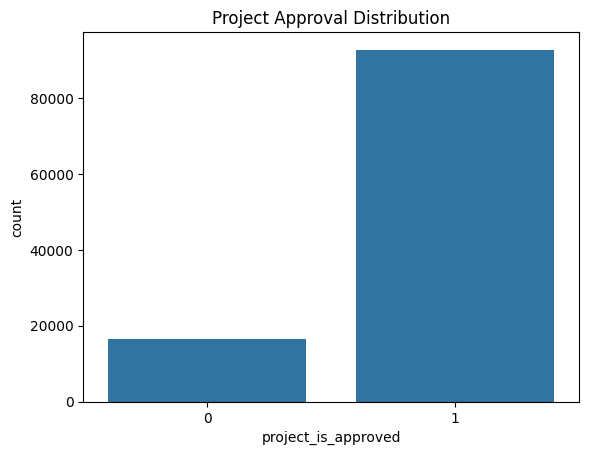

In [10]:
sns.countplot(x="project_is_approved", data=df_donors)
plt.title("Project Approval Distribution")
plt.show()

In [11]:
df_donors["teacher_prefix"].value_counts()

,count
teacher_prefix,
mrs,57272
ms,38955
mr,10648
teacher,2360
dr,13


In [12]:
text_column = "cleaned_essays"

# Preprocessing

In [13]:
df_donors["cleaned_titles"] = df_donors["cleaned_titles"].str.replace("_", " ", regex=False)
df_donors["cleaned_summary"] = df_donors["cleaned_summary"].str.replace("_", " ", regex=False)
df_donors["cleaned_essays"] = df_donors["cleaned_essays"].str.replace("_", " ", regex=False)

In [14]:
# Instead of building three different TF-IDF or Word2Vec
df_donors["combined_text"] = (df_donors["cleaned_titles"] + " " + df_donors["cleaned_summary"] + " " + df_donors["cleaned_essays"])
df_donors["combined_text"].head()

,combined_text
0,educational support english learners home stud...
1,wanted projector hungry learners students need...
2,soccer equipment awesome middle school student...
3,techie kindergarteners students need engage re...
4,interactive math tools students need hands pra...


In [15]:
print(repr(df_donors["combined_text"].iloc[0]))

'educational support english learners home students need opportunities practice beginning reading skills english home students english learners working english second third languages melting pot refugees immigrants native born americans bringing gift language school 24 languages represented english learner program students every level mastery also 40 countries represented families within school student brings wealth knowledge experiences us open eyes new cultures beliefs respect limits language limits world ludwig wittgenstein english learner strong support system home begs resources many times parents learning read speak english along side children sometimes creates barriers parents able help child learn phonetics letter recognition reading skills providing dvd players students able continue mastery english language even no one home able assist families students within level 1 proficiency status offered part program educational videos specially chosen english learner teacher sent home

## Punctuation Removal

In [16]:
def remove_punctuation(text):
    return "".join(char for char in text if char not in string.punctuation)
df_donors["punctuation_removed"] = df_donors["combined_text"].apply(remove_punctuation)
df_donors[["combined_text", "punctuation_removed"]].head()

,combined_text,punctuation_removed
0,educational support english learners home stud...,educational support english learners home stud...
1,wanted projector hungry learners students need...,wanted projector hungry learners students need...
2,soccer equipment awesome middle school student...,soccer equipment awesome middle school student...
3,techie kindergarteners students need engage re...,techie kindergarteners students need engage re...
4,interactive math tools students need hands pra...,interactive math tools students need hands pra...


## Lowercase

In [17]:
df_donors["tokens"] = df_donors["punctuation_removed"].apply(lambda x: word_tokenize(x.lower()))
df_donors["tokens"].head()

,tokens
0,"[educational, support, english, learners, home..."
1,"[wanted, projector, hungry, learners, students..."
2,"[soccer, equipment, awesome, middle, school, s..."
3,"[techie, kindergarteners, students, need, enga..."
4,"[interactive, math, tools, students, need, han..."


## Lemmatization

In [18]:
lemmatizer = WordNetLemmatizer()
def lemmatize_words(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

In [19]:
df_donors["lemmatized_tokens"] = df_donors["tokens"].apply(lemmatize_words)
df_donors["lemmatized_tokens"].head()

,lemmatized_tokens
0,"[educational, support, english, learner, home,..."
1,"[wanted, projector, hungry, learner, student, ..."
2,"[soccer, equipment, awesome, middle, school, s..."
3,"[techie, kindergartener, student, need, engage..."
4,"[interactive, math, tool, student, need, hand,..."


In [20]:
df_donors["lemmatized_tokens"] = df_donors["lemmatized_tokens"].apply(lambda tokens: [word for word in tokens if not re.search(r"\d", word)])

In [21]:
df_donors["lemmatized_tokens"].head()

,lemmatized_tokens
0,"[educational, support, english, learner, home,..."
1,"[wanted, projector, hungry, learner, student, ..."
2,"[soccer, equipment, awesome, middle, school, s..."
3,"[techie, kindergartener, student, need, engage..."
4,"[interactive, math, tool, student, need, hand,..."


# TF-IDF

### Embedding

In [22]:
df_donors["final_text"] = df_donors["lemmatized_tokens"].apply(" ".join)    # # Joined tokens back into sentences
df_donors["final_text"].head()
df_donors["final_text"].head()

,final_text
0,educational support english learner home stude...
1,wanted projector hungry learner student need p...
2,soccer equipment awesome middle school student...
3,techie kindergartener student need engage read...
4,interactive math tool student need hand practi...


In [23]:
# 1-gram
tfidf_uni = TfidfVectorizer(ngram_range=(1,1),max_features=50000)
X_tfidf_uni = tfidf_uni.fit_transform(df_donors["final_text"])
X_tfidf_uni.shape

(109248, 50000)

In [24]:
print("Total unigram features:", len(tfidf_uni.get_feature_names_out()))
tfidf_uni.get_feature_names_out()[:20]

Total unigram features: 50000


array(['aa', 'aaa', 'aaamath', 'aac', 'aafai', 'aagain', 'aahhhhh',
       'aappl', 'aardvark', 'aargh', 'aaron', 'aarows', 'aarp', 'aart',
       'aasl', 'aaw', 'ab', 'aba', 'abab', 'aback'], dtype=object)

In [25]:
# 2-gram
tfidf_bi = TfidfVectorizer(ngram_range=(2,2),max_features=50000)
X_tfidf_bi = tfidf_bi.fit_transform(df_donors["final_text"])
X_tfidf_bi.shape

(109248, 50000)

In [26]:
print("Total bigram features:", len(tfidf_bi.get_feature_names_out()))
tfidf_bi.get_feature_names_out()[:20]

Total bigram features: 50000


array(['abc mouse', 'abc student', 'ability able', 'ability access',
       'ability achieve', 'ability also', 'ability attend',
       'ability background', 'ability become', 'ability book',
       'ability bring', 'ability building', 'ability challenge',
       'ability change', 'ability child', 'ability choose',
       'ability class', 'ability classroom', 'ability climb',
       'ability collaborate'], dtype=object)

In [27]:
# 3-gram
tfidf_tri = TfidfVectorizer(ngram_range=(3,3),max_features=50000)
X_tfidf_tri = tfidf_tri.fit_transform(df_donors["final_text"])
X_tfidf_tri.shape

(109248, 50000)

In [28]:
print("Total trigram features:", len(tfidf_tri.get_feature_names_out()))
tfidf_tri.get_feature_names_out()[:20]

Total trigram features: 50000


array(['abc student need', 'ability building drawing',
       'ability classroom student', 'ability climb tree',
       'ability come school', 'ability communicate effectively',
       'ability design create', 'ability focus learn',
       'ability focus learning', 'ability focus student',
       'ability focus work', 'ability gifted special',
       'ability help student', 'ability interest challenge',
       'ability learn grow', 'ability learn new', 'ability learn student',
       'ability learning style', 'ability level classroom',
       'ability level come'], dtype=object)

In [29]:
tfidf = TfidfVectorizer(ngram_range=(1,2),max_features=50000)
X_tfidf = tfidf.fit_transform(df_donors["final_text"])
print(X_tfidf.shape)

(109248, 50000)


# Word2Vec

In [30]:
sentences = df_donors["lemmatized_tokens"].tolist()
word2vec_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [31]:
len(word2vec_model.wv)

32331

In [32]:
word2vec_model.wv.most_similar("student", topn=5)

[('child', 0.6895391941070557),
 ('kid', 0.6138854026794434),
 ('melded', 0.608154296875),
 ('loquacious', 0.6000402569770813),
 ('kiddos', 0.5760082006454468)]

In [33]:
print(df_donors["final_text"].iloc[0])

educational support english learner home student need opportunity practice beginning reading skill english home student english learner working english second third language melting pot refugee immigrant native born american bringing gift language school language represented english learner program student every level mastery also country represented family within school student brings wealth knowledge experience u open eye new culture belief respect limit language limit world ludwig wittgenstein english learner strong support system home begs resource many time parent learning read speak english along side child sometimes creates barrier parent able help child learn phonetics letter recognition reading skill providing dvd player student able continue mastery english language even no one home able assist family student within level proficiency status offered part program educational video specially chosen english learner teacher sent home regularly watch video help child develop early 

# Model Building

In [34]:
# Target
y = df_donors["project_is_approved"]
y.value_counts()

,count
project_is_approved,
1,92706
0,16542


In [35]:
X = X_tfidf      # 1-2 gram TF-IDF matrix
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print(X_train.shape)
print(X_test.shape)

(87398, 50000)
(21850, 50000)


In [36]:
lr = LogisticRegression(class_weight="balanced",max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [37]:
y_pred_lr = lr.predict(X_test)

# Evaluation

In [38]:
print("Accuracy\t: ", accuracy_score(y_test, y_pred_lr))
print("Precision \t: ", precision_score(y_test, y_pred_lr))
print("Recall\t\t: ", recall_score(y_test, y_pred_lr))
print("F1 Score \t: ", f1_score(y_test, y_pred_lr))

Accuracy	:  0.7253546910755149
Precision 	:  0.908209100969989
Recall		:  0.7523999568547083
F1 Score 	:  0.8229950151903961


In [39]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.29      0.57      0.39      3308
           1       0.91      0.75      0.82     18542

    accuracy                           0.73     21850
   macro avg       0.60      0.66      0.61     21850
weighted avg       0.81      0.73      0.76     21850



In [40]:
cm = confusion_matrix(y_test, y_pred_lr)
cm

array([[ 1898,  1410],
       [ 4591, 13951]])

In [41]:
#               Predicted
#              0         1
# Actual 0   TN=169   FP=3139
# Actual 1   FN=137   TP=18405

# 169 + 3139 = 3308
# 137 + 18405 = 18542
# 3308 + 18542 = 21850

# Class 0 - Not Approved                         |        Class 1 - Approved
# There were 3308 projects                       |        There were 18542 projects
# Correctly predicted = 169                      |        Correctly predicted = 18405
# Incorrectly predicted as approved = 3139       |        Incorrectly predicted = 137

In [42]:
# ROC curve
probabilities = lr.predict_proba(X_test)
y_prob_lr = probabilities[:,1]     # Predicts probabilities, [:, 1] = [rows columns]

In [43]:
# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)     # False Positive Rates - X-axis, True Positive Rates - Y-axis
auc_score = roc_auc_score(y_test, y_prob_lr)    # area under the ROC curve
print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.7242841083552005


In [44]:
# Auc = 0.72 => model is "good" at separating approved and not-approved projects

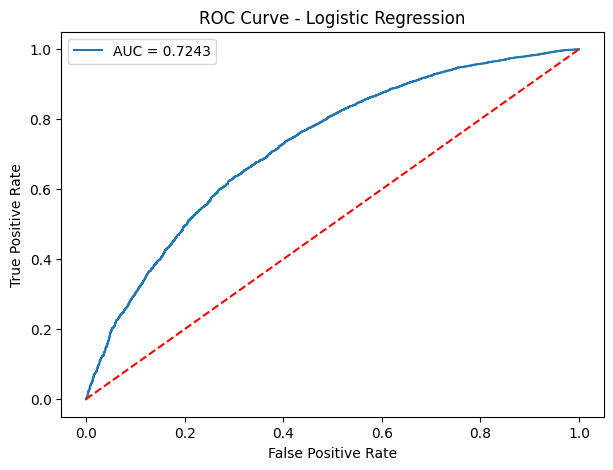

In [45]:
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0,1],[0,1],'r--')     # r-- = red dashed line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

In [46]:
svm = LinearSVC()
svm.fit(X_train, y_train)

LinearSVC()

In [47]:
y_pred_svm = svm.predict(X_test)

In [48]:
print("Accuracy\t: ", accuracy_score(y_test, y_pred_svm))
print("Precision \t: ", precision_score(y_test, y_pred_svm))
print("Recall\t\t: ", recall_score(y_test, y_pred_svm))
print("F1 Score \t: ", f1_score(y_test, y_pred_svm))

Accuracy	:  0.8353775743707094
Precision 	:  0.8637492089762936
Recall		:  0.9569625714593895
F1 Score 	:  0.9079698093897914


In [49]:
print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.39      0.15      0.22      3308
           1       0.86      0.96      0.91     18542

    accuracy                           0.84     21850
   macro avg       0.63      0.56      0.56     21850
weighted avg       0.79      0.84      0.80     21850



In [50]:
# SVM achieved 83.5% accuracy and performed well on the majority class which is "approved projects", but its performance on the minority class that is "not approved" was poor because of "class imbalance"

### Deep Learning

In [51]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     6,400,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,408,449 (24.45 MB)

 Trainable params: 6,408,449 (24.45 MB)

 Non-trainable params: 0 (0.00 B)

In [52]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train the  model
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
2185/2185 ━━━━━━━━━━━━━━━━━━━━ 1023s 467ms/step - accuracy: 0.8492 - loss: 0.3954 - val_accuracy: 0.8508 - val_loss: 0.3784
Epoch 2/10
2185/2185 ━━━━━━━━━━━━━━━━━━━━ 188s 86ms/step - accuracy: 0.8753 - loss: 0.3027 - val_accuracy: 0.8391 - val_loss: 0.4068
Epoch 3/10
 889/2185 ━━━━━━━━━━━━━━━━━━━━ 1:09 54ms/step - accuracy: 0.9314 - loss: 0.1844